In [3]:
import pandas as pd
from rapidfuzz import fuzz, process

# Load dataset
df = pd.read_csv(r"C:\Users\Priyanshi Tomar\Desktop\trial.csv", encoding= 'unicode_escape')

# Example predefined drug terms
drug_terms = ['fentanyl', 'meth', 'cocaine', 'heroin', 'xanax','weed', 'marijuana', 'cannabis', '420', 'molly', 'ketamine', 'percs',  'shrooms', 'tabs', 'plug',
    'meds', 'scripts', 'zaza',   'pharmacyconnect',
    'deliveries', 'onsale',  'discreetshipping', 'localplug',
    'edibles', 'carts', 'pressedpills', 'rcs', 'exotic', 'moonrocks',
    'shroomstagram', 'shrooms', 'mushrooms', 'shroomstrip', 'mycology', 'fungi', 'magicmushrooms',
    'mushroomsofinstagram', 'trippy', 'psilocybinmushrooms',
    'lsd', 'cubensis', 'psilocybin']

# Function to detect derivatives/extended forms
def detect_variants(text, drug_terms, threshold=60):
    if not isinstance(text, str):  # Handle NaN or non-string cases
        return []
    
    tokens = text.split()  # Tokenize text
    matches = []
    
    for token in tokens:
        # Partial matching for the whole word
        match, score, _ = process.extractOne(token, drug_terms, scorer=fuzz.partial_ratio)
        if score >= threshold:  # Consider a match if above threshold
            matches.append((token, match, score / 100))
        
        # Substring matching
        for term in drug_terms:
            if term in token.lower():  # Check if the term is a substring
                matches.append((token, term, fuzz.partial_ratio(term, token.lower()) / 100))
    
    return matches

# Apply the function
df['keyword_matches'] = df['text'].apply(lambda x: detect_variants(x, drug_terms))

# Flatten the results into a new DataFrame
results = []
for _, row in df.iterrows():
    for keyword, matched_term, score in row['keyword_matches']:
        results.append({'Keyword': keyword, 'Related Term': matched_term, 'Score': score})

# Create DataFrame and save to CSV
output_df = pd.DataFrame(results).drop_duplicates()
output_df.to_csv(r"C:\Users\Priyanshi Tomar\Desktop\Fuzzfinal.csv", index=False)

print("Fine-tuned keyword matches saved to 'Fuzzfinal.csv'")


Fine-tuned keyword matches saved to 'Fuzzfinal.csv'


In [6]:
import pandas as pd

data = pd.read_csv(r"C:\Users\Priyanshi Tomar\Desktop\Fuzzfinal.csv")

df_fuzz = pd.DataFrame(data)

print(df_fuzz.describe())

            Score
count  666.000000
mean     0.726765
std      0.109940
min      0.600000
25%      0.666667
50%      0.666667
75%      0.769231
max      1.000000


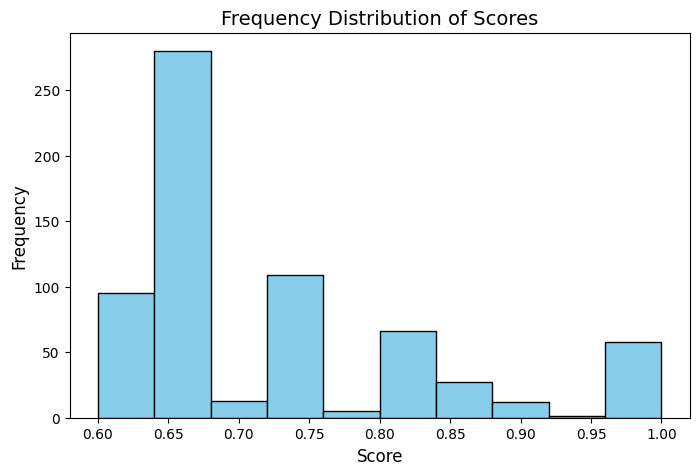

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(data['Score'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Frequency Distribution of Scores', fontsize=14)
plt.show()




C:\Users\Priyanshi Tomar\AppData\Local\Temp\ipykernel_100876\681692758.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data['Score'], shade=True, color='skyblue')


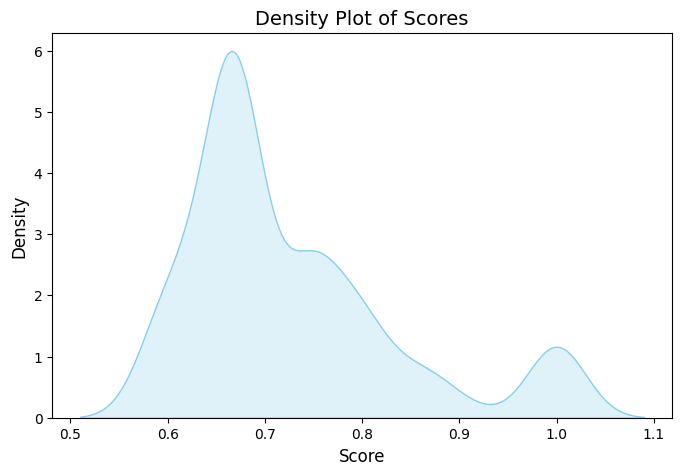

In [9]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(data['Score'], shade=True, color='skyblue')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Density Plot of Scores', fontsize=14)
plt.show()


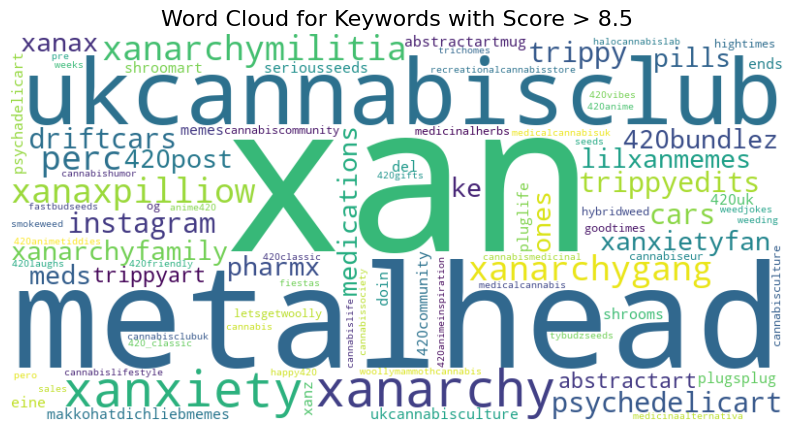

In [14]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
data = pd.read_csv(r"C:\Users\Priyanshi Tomar\Desktop\Fuzzfinal.csv")

df_fuzz = pd.DataFrame(data)

# Filter keywords with a score greater than 8.5
filtered_data = data[data['Score'] > 0.85]

# Combine all keywords into a single string
keywords_string = ' '.join(filtered_data['Keyword'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(keywords_string)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.title('Word Cloud for Keywords with Score > 8.5', fontsize=16)
plt.show()
